# Assignment Four — Faculty Salaries Analysis

**Susana Rivera** — Python Analytics Class — September 2026

In this notebook I explore the **Salaries** dataset: salaries for 397 college professors, with their rank, discipline, years since PhD, years of service, and sex.

The assignment has four parts:

1. **Data exploration** — mean and median of all salaries, median salary by sex and by rank
2. **Data wrangling** — renaming columns, subsetting columns, handling missing data
3. **Data visualizations** — charts that show some of the stats
4. **Conclusions** — what I discovered

## 0. Load the data

I import pandas for the data work and matplotlib for the charts, then read the CSV straight from the class GitHub page into a dataframe called `df`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Make every chart use large text so it is easy to read
plt.rcParams.update({'font.size': 14, 'figure.figsize': (10, 6)})

df = pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/Salaries.csv')

## 1. Data exploration

First I look at the data before doing anything to it.
`head()` shows the first five rows, `shape` tells me how many rows and columns there are, `info()` shows the column types, and `describe()` gives quick statistics for every number column.

In [2]:
df.head()

,Unnamed: 0,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,1,Prof,B,19,18,Male,139750
1,2,Prof,B,20,16,Male,173200
2,3,AsstProf,B,4,3,Male,79750
3,4,Prof,B,45,39,Male,115000
4,5,Prof,B,40,41,Male,141500


In [3]:
df.shape

(397, 7)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Unnamed: 0     397 non-null    int64
 1   rank           397 non-null    str  
 2   discipline     397 non-null    str  
 3   yrs.since.phd  397 non-null    int64
 4   yrs.service    397 non-null    int64
 5   sex            397 non-null    str  
 6   salary         397 non-null    int64
dtypes: int64(4), str(3)
memory usage: 26.0 KB


In [5]:
df.describe()

,Unnamed: 0,yrs.since.phd,yrs.service,salary
count,397.000000,397.000000,397.000000,397.000000
mean,199.000000,22.314861,17.614610,113706.458438
std,114.748275,12.887003,13.006024,30289.038695
min,1.000000,1.000000,0.000000,57800.000000
25%,100.000000,12.000000,7.000000,91000.000000
50%,199.000000,21.000000,16.000000,107300.000000
75%,298.000000,32.000000,27.000000,134185.000000
max,397.000000,56.000000,60.000000,231545.000000


### Mean and median of all salaries

The **mean** is the average. The **median** is the middle value when all salaries are sorted.
When the mean is higher than the median, it means a few very high salaries are pulling the average up.

In [6]:
mean_salary = df['salary'].mean()
median_salary = df['salary'].median()

print(f'Mean (average) salary: ${mean_salary:,.0f}')
print(f'Median salary:         ${median_salary:,.0f}')
print(f'Lowest salary:         ${df["salary"].min():,.0f}')
print(f'Highest salary:        ${df["salary"].max():,.0f}')

Mean (average) salary: $113,706
Median salary:         $107,300
Lowest salary:         $57,800
Highest salary:        $231,545


### How many professors are in each group?

`value_counts()` counts how many rows there are for each value in a column.

In [7]:
print(df['rank'].value_counts())
print()
print(df['sex'].value_counts())
print()
print(df['discipline'].value_counts())

rank
Prof         266
AsstProf      67
AssocProf     64
Name: count, dtype: int64

sex
Male      358
Female     39
Name: count, dtype: int64

discipline
B    216
A    181
Name: count, dtype: int64


### Median salary by sex

`groupby('sex')` splits the data into a Male group and a Female group, then `median()` finds the middle salary in each group.

In [8]:
df.groupby('sex')['salary'].median()

sex
Female    103750.0
Male      108043.0
Name: salary, dtype: float64

### Median salary by rank

The three ranks, from most junior to most senior, are **AsstProf** (assistant professor), **AssocProf** (associate professor), and **Prof** (full professor).

In [9]:
df.groupby('rank')['salary'].median().sort_values()

rank
AsstProf      79800.0
AssocProf     95626.5
Prof         123321.5
Name: salary, dtype: float64

### Median salary by rank AND sex

Grouping by two columns at once lets me compare men and women who hold the same rank.
`unstack()` turns the result into an easy-to-read table.

In [10]:
df.groupby(['rank', 'sex'])['salary'].median().unstack()

sex,Female,Male
rank,,
AssocProf,90556.5,95626.5
AsstProf,77000.0,80182.0
Prof,120257.5,123996.0


## 2. Data wrangling

### Renaming columns

The first column has no name — pandas called it `Unnamed: 0`. It is just a row ID, so I name it `id`.
The other column names use dots (`yrs.since.phd`), which are awkward in Python, so I rename them to clearer names with underscores.

In [11]:
df = df.rename(columns={
    'Unnamed: 0': 'id',
    'yrs.since.phd': 'years_since_phd',
    'yrs.service': 'years_of_service',
})
df.head()

,id,rank,discipline,years_since_phd,years_of_service,sex,salary
0,1,Prof,B,19,18,Male,139750
1,2,Prof,B,20,16,Male,173200
2,3,AsstProf,B,4,3,Male,79750
3,4,Prof,B,45,39,Male,115000
4,5,Prof,B,40,41,Male,141500


### Handling missing data

`isna().sum()` counts the empty (missing) values in each column.
If there were any, I would either drop those rows with `dropna()` or fill them in with `fillna()`.

In [12]:
df.isna().sum()

id                  0
rank                0
discipline          0
years_since_phd     0
years_of_service    0
sex                 0
salary              0
dtype: int64

In [13]:
missing_total = df.isna().sum().sum()
if missing_total == 0:
    print('Good news: there are no missing values, so nothing needs to be dropped or filled.')
else:
    df = df.dropna()
    print(f'Dropped rows with missing values. {len(df)} rows remain.')

Good news: there are no missing values, so nothing needs to be dropped or filled.


### Subsetting columns

For the rest of the analysis I only need four columns: rank, sex, years of service, and salary.
I put them in a new, smaller dataframe called `pay`.

In [14]:
pay = df[['rank', 'sex', 'years_of_service', 'salary']]
pay.head()

,rank,sex,years_of_service,salary
0,Prof,Male,18,139750
1,Prof,Male,16,173200
2,AsstProf,Male,3,79750
3,Prof,Male,39,115000
4,Prof,Male,41,141500


### Filtering rows

Filtering means keeping only the rows that match a condition. Here I keep only the female professors and look at their statistics.

In [15]:
women = pay[pay['sex'] == 'Female']
print(f'Number of female professors: {len(women)} out of {len(pay)}')
women.describe()

Number of female professors: 39 out of 397


,years_of_service,salary
count,39.000000,39.000000
mean,11.564103,101002.410256
std,8.813252,25952.127317
min,0.000000,62884.000000
25%,4.000000,77250.000000
50%,10.000000,103750.000000
75%,17.500000,117002.500000
max,36.000000,161101.000000


## 3. Data visualizations

### Chart 1 — Median salary by rank

A bar chart makes it easy to see how much salary grows with rank.

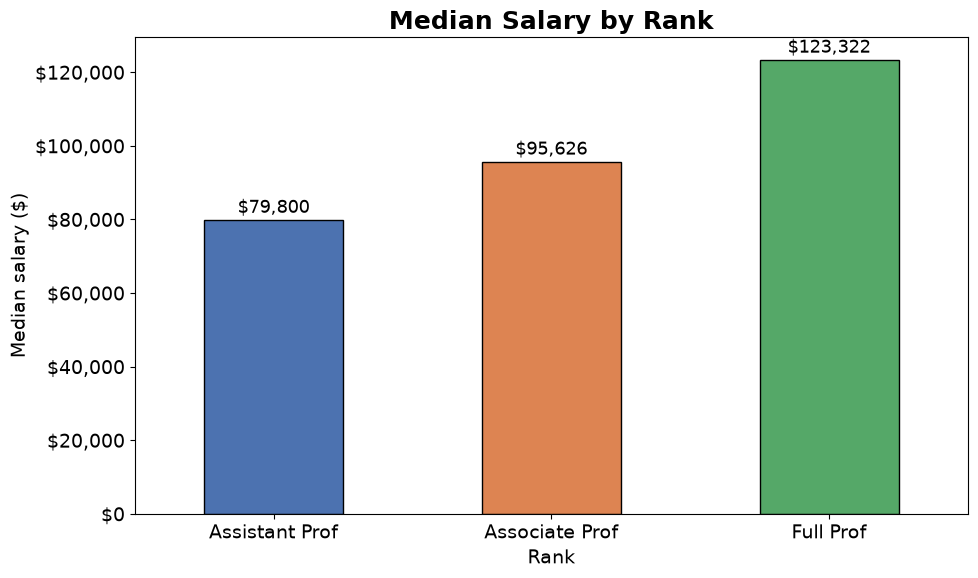

In [16]:
from matplotlib.ticker import StrMethodFormatter

median_by_rank = pay.groupby('rank')['salary'].median().reindex(['AsstProf', 'AssocProf', 'Prof'])

ax = median_by_rank.plot(kind='bar', color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='black')
ax.set_title('Median Salary by Rank', fontsize=18, fontweight='bold')
ax.set_xlabel('Rank')
ax.set_ylabel('Median salary ($)')
ax.set_xticklabels(['Assistant Prof', 'Associate Prof', 'Full Prof'], rotation=0)
ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
for i, value in enumerate(median_by_rank):
    ax.text(i, value + 2000, f'${value:,.0f}', ha='center', fontsize=13)
plt.tight_layout()
plt.show()

### Chart 2 — Salary by sex

A box plot shows the whole spread of salaries, not just one number.
The line inside each box is the median, the box covers the middle half of the salaries, and the dots are unusual values (outliers).

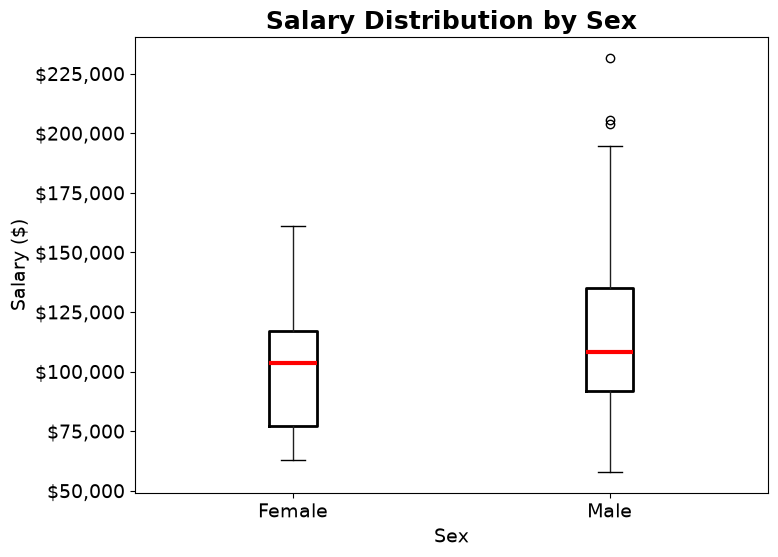

In [17]:
ax = pay.boxplot(column='salary', by='sex', figsize=(8, 6), grid=False,
                 boxprops={'linewidth': 2}, medianprops={'linewidth': 3, 'color': 'red'})
ax.set_title('Salary Distribution by Sex', fontsize=18, fontweight='bold')
plt.suptitle('')
ax.set_xlabel('Sex')
ax.set_ylabel('Salary ($)')
ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.tight_layout()
plt.show()

### Chart 3 — Does salary go up with years of service?

A scatter plot puts one dot per professor. Each dot is colored by rank so I can see the three groups.

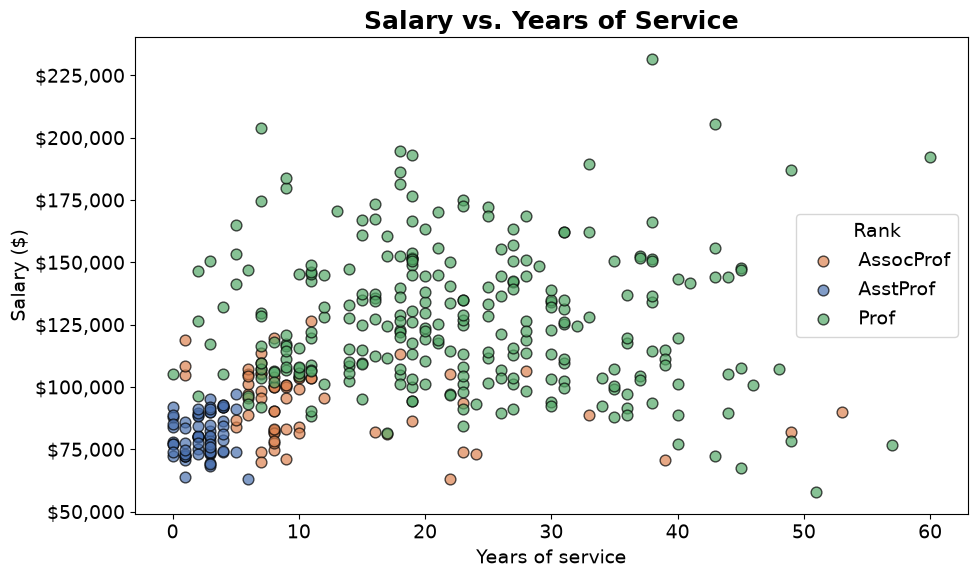

In [18]:
colors = {'AsstProf': '#4C72B0', 'AssocProf': '#DD8452', 'Prof': '#55A868'}

fig, ax = plt.subplots()
for rank_name, group in pay.groupby('rank'):
    ax.scatter(group['years_of_service'], group['salary'],
               label=rank_name, color=colors[rank_name], s=60, alpha=0.7, edgecolor='black')
ax.set_title('Salary vs. Years of Service', fontsize=18, fontweight='bold')
ax.set_xlabel('Years of service')
ax.set_ylabel('Salary ($)')
ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax.legend(title='Rank')
plt.tight_layout()
plt.show()

## 4. Conclusions — what did I discover?

- **The typical professor earns about $107,000.** The mean ($113,706) is higher than the median ($107,300), which tells me a handful of very high salaries pull the average up. The top salary is $231,545.
- **Rank matters most.** Median salary climbs from about $79,800 for assistant professors, to $95,600 for associate professors, to $123,300 for full professors. Chart 1 shows this step-by-step increase clearly.
- **Women are a small minority and earn a bit less.** Only 39 of the 397 professors are women. Their median salary ($103,750) is about $4,300 below the men's ($108,043). The gap does not go away when I compare within the same rank: women's median is about $3,000 to $5,000 lower at every rank (assistant, associate, and full professor).
- **More years of service does not automatically mean more pay.** In Chart 3 the dots spread widely: some professors with 30+ years earn less than others with 10 years. Rank explains salary better than years alone.
- **The data was clean.** There were no missing values, so the wrangling step was mainly renaming the awkward column names and picking the columns I needed.